# IMPORT DATASET


In [3]:
!pip install -q scikit-learn pandas numpy

import pandas as pd
import numpy as np

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# LOAD DATASET

In [4]:
X, y = fetch_openml("titanic", version=1, as_frame=True, return_X_y=True)

# Select useful columns
X = X[["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]]

print(X.head())
print(y.head())

   pclass     sex      age  sibsp  parch      fare embarked
0       1  female  29.0000      0      0  211.3375        S
1       1    male   0.9167      1      2  151.5500        S
2       1  female   2.0000      1      2  151.5500        S
3       1    male  30.0000      1      2  151.5500        S
4       1  female  25.0000      1      2  151.5500        S
0    1
1    1
2    0
3    0
4    0
Name: survived, dtype: category
Categories (2, object): ['0', '1']


#TRAIN TEST SPLIT

In [12]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#PREPROCESSING PIPELINE

In [6]:
numeric_features = ["age", "fare", "sibsp", "parch"]
categorical_features = ["pclass", "sex", "embarked"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

#DIFFERENT MODELS

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Gradient Boosting": GradientBoostingClassifier()
}

#TRAINING AND EVALUATUION

In [8]:
from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.8053
Decision Tree Accuracy: 0.7939
Random Forest Accuracy: 0.7901
KNN Accuracy: 0.7939
SVM Accuracy: 0.8397
Gradient Boosting Accuracy: 0.8092


#COMPARE MODELS

In [10]:
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)

print("\n🔥 Model Ranking:")
for name, acc in sorted_results:
    print(f"{name}: {acc:.4f}")


🔥 Model Ranking:
SVM: 0.8397
Gradient Boosting: 0.8092
Logistic Regression: 0.8053
Decision Tree: 0.7939
KNN: 0.7939
Random Forest: 0.7901


#CONFUSION MATRIX


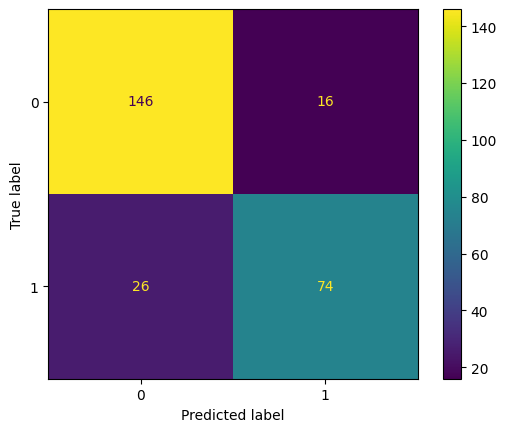

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model_name = sorted_results[0][0]
best_model = models[best_model_name]

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

pipe.fit(X_train, y_train)
ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test)
plt.show()